# Non-Autonomous Terms and VF-b Test
This notebook uses the best candidates from SINDy_FHN.ipynb for fitting data.  These include the following options:
* Model - VF-b (most realistic FHN model)
* Optimizer - SSR
* feature_library - degree 3 polynomials

In [150]:
import math
import numpy as np
import functools
from scipy.integrate import odeint
from scipy import fft
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt
import pandas as pd
import importlib
import SINDy
importlib.reload(SINDy)

import pysindy as ps

In [ ]:
# The old, non-truncated autonomous term (can be a problem for large exponents).
# Params:
#   t (1d array): Time input vector
#   mag (float): The magnitude of the stimulus
def smooth_non_aut_old(t, mag=0.12):
    return 2. * mag / (1. + np.exp((25*np.sin(0.02*t))**2))

# A differentiable non-autonomous term truncated from the Taylor series of the above term.
# Params:
#   t (1d array): Time input vector
#   mag (float): The magnitude of the stimulus
def smooth_non_aut(t, mag=0.12):
    return 2. * mag / (2. + (200.*np.sin(0.02*t))**4)

# Logical step function non-autonomous term.
# Params:
#   t (1d array): Time input vector
#   period (float): The period of the stimulus
#   dur (float): The time duration of the stimulus
#   mag (float): The magnitude of the stimulus
def logical_non_aut(t, period=155.0, dur=5.0, mag=0.12):
    stimulus = mag * (np.mod(t, period) <= dur)
    return stimulus

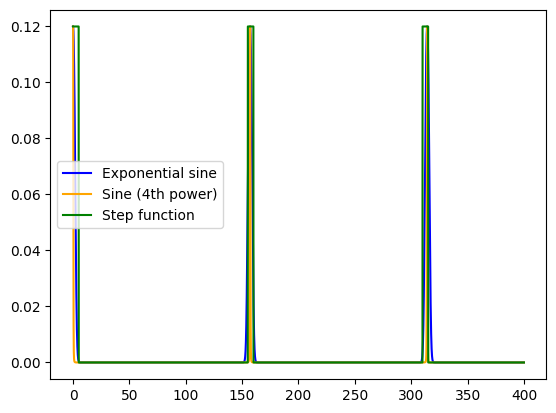

In [ ]:
# Compare the forcing functions. Note that we can't actually use the exponential since it will encounter overflow for the peak tightness
# that we need; instead, take part of the Taylor series, then throw out the terms we don't need while still maintaing a representative shape.
t = np.arange(0,400,0.01)
plt.plot(t, smooth_non_aut_old(t), color = 'blue', label='Exponential sine')
plt.plot(t, smooth_non_aut(t), color='orange', label='Sine (4th power)')
plt.plot(t, logical_non_aut(t), color='green', label='Step function')
plt.legend()

# 1.) VF-FHN
Now, let's try fitting the above with some non-autonomous terms included.

In [ ]:
'''
Generate the data using the VF-b modified FHN equations:
Params:
    state (2d array):        Contains the state variables u and v
    t (1d array):            Time input
    non_aut_term (1d array): A non-autonomous term to be added to the u_dot equation
    alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 1.0, eps = 0.005, theta = -0.05, mu = 1.0 (Old auto-oscillatory parameters used to get these equations)
'''
def fhn_vf_b(state, t, non_aut_term, alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 0.0, eps = 0.005, theta = -0.05, mu = 1.0):
    u, v = state
    u_dot = mu*u*(1 - u)*(u - alpha) - u*v  # Note - The cardiac version without hyperpolarization (FHN-c) has -u*v instead of -v. ID success can change depending on which variant we use.
    v_dot = eps*((beta - u)*(u - gamma) - delta*v - theta)

    # Add time-dependent voltage perturbation
    u_dot +=  non_aut_term(t)
    return u_dot, v_dot

# Time step and initial values; seems like 0-600 is minimum timeframe needed to identify dynamics
dt = 0.01
t_vf_b = np.arange(0,2000,dt)
x_0_vf_b = np.array([0,0])

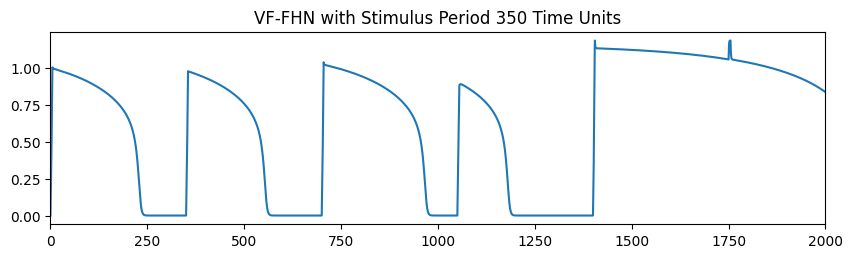

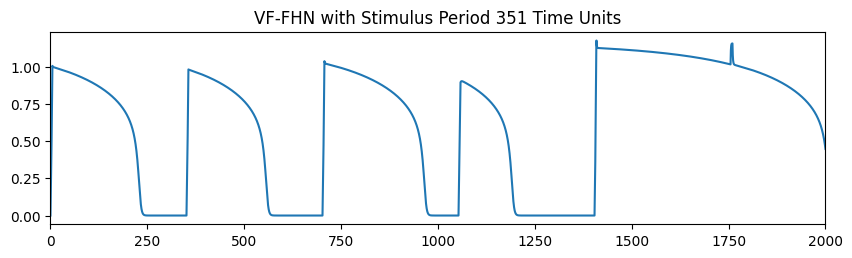

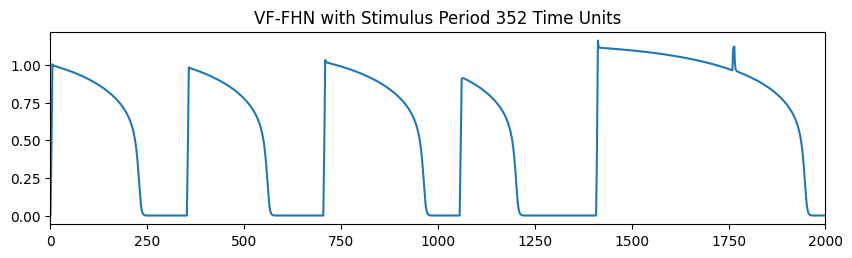

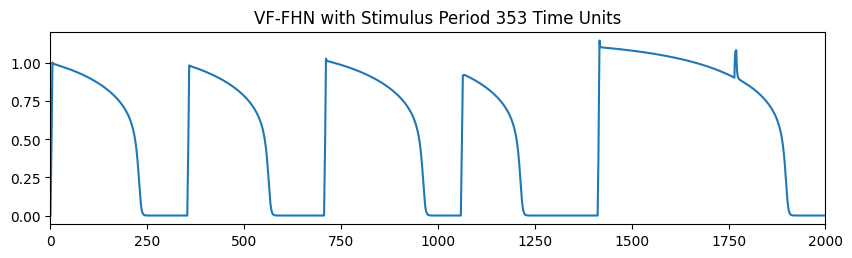

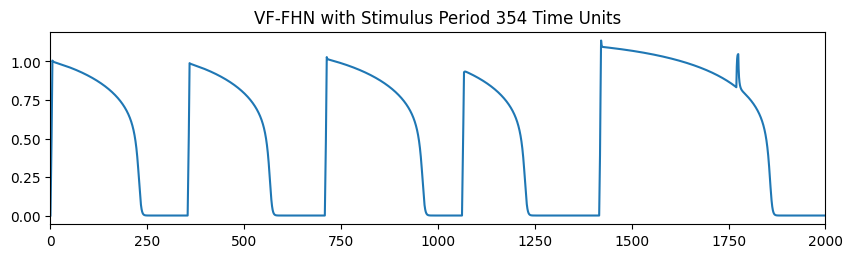

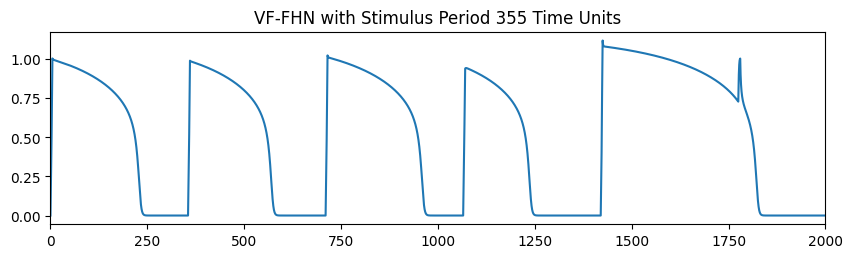

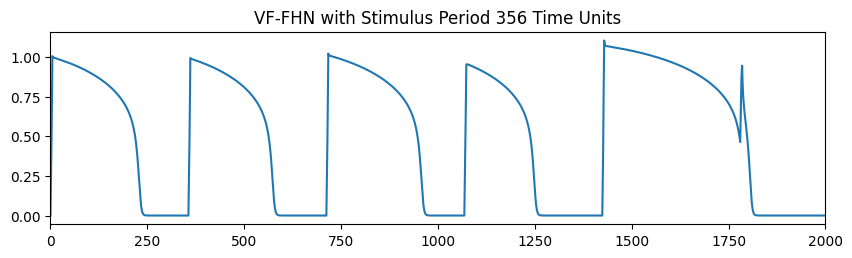

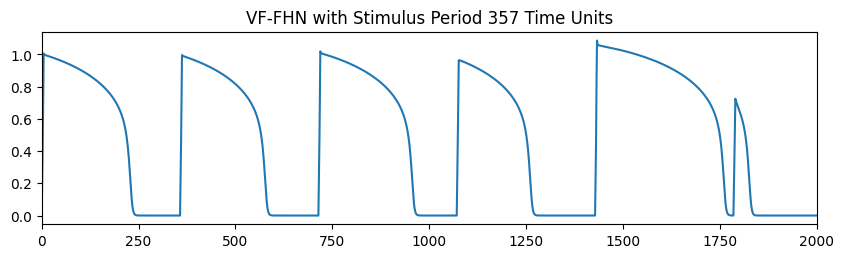

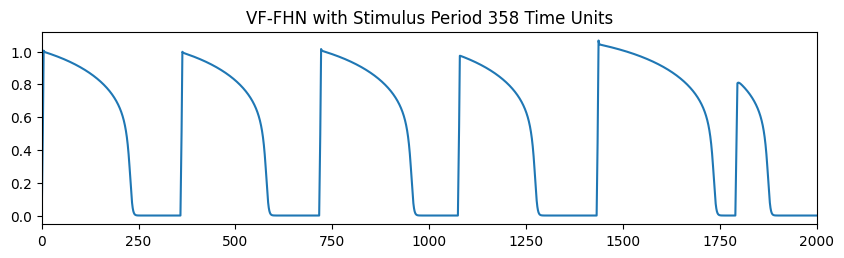

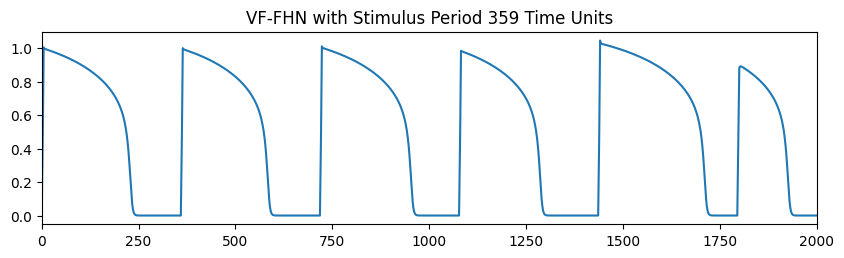

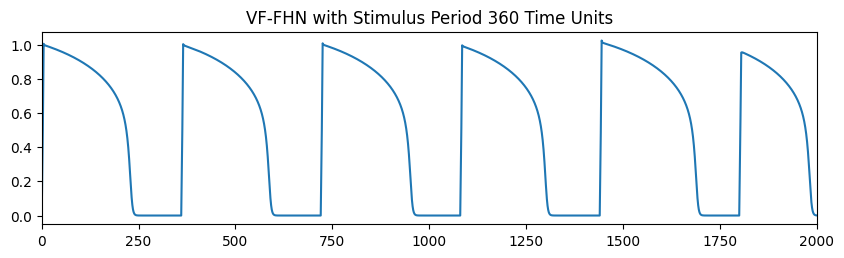

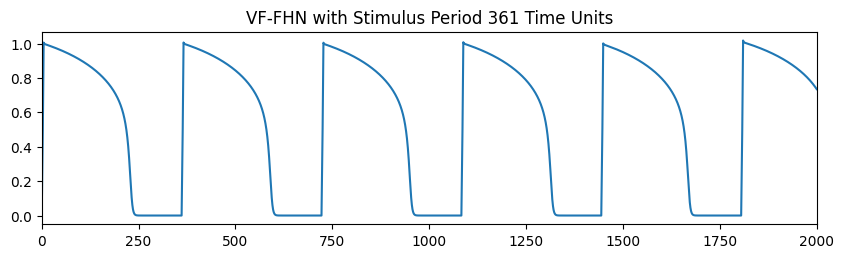

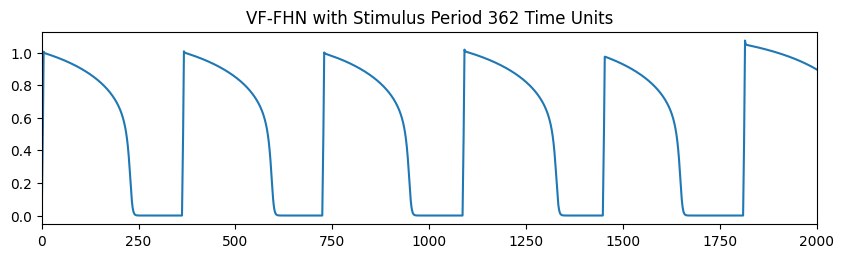

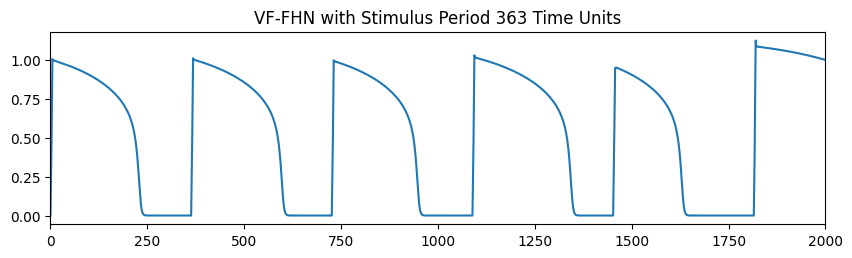

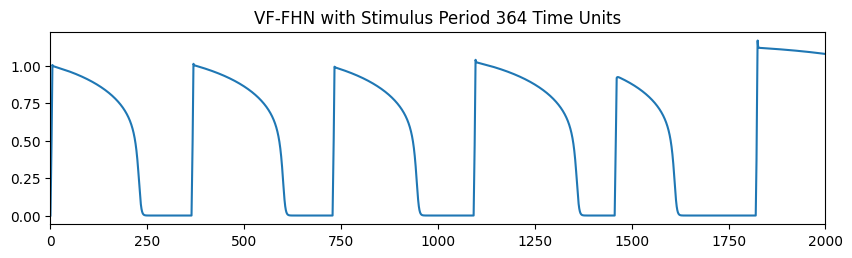

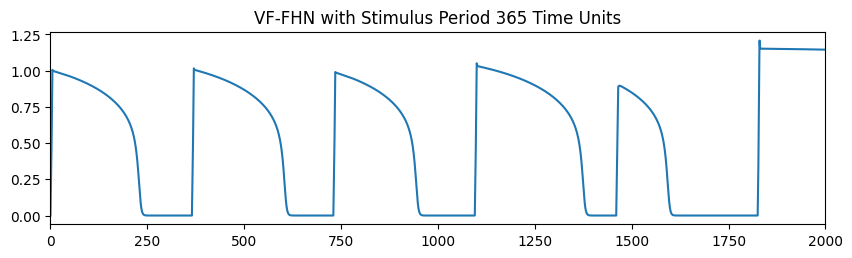

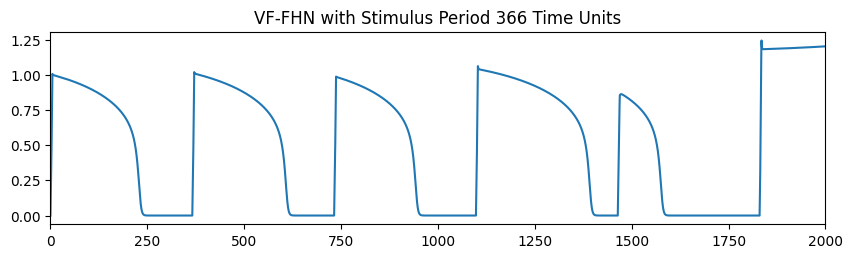

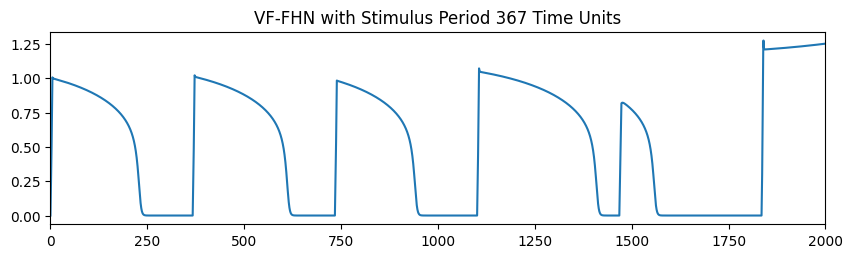

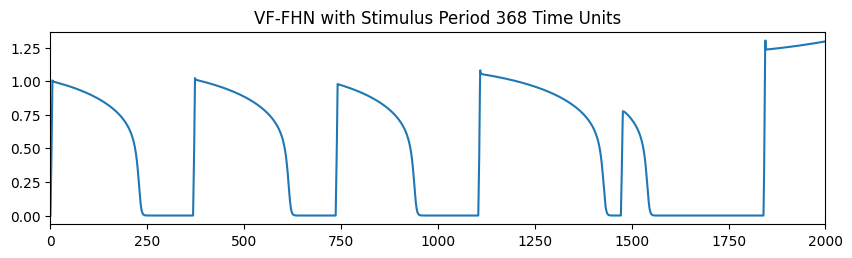

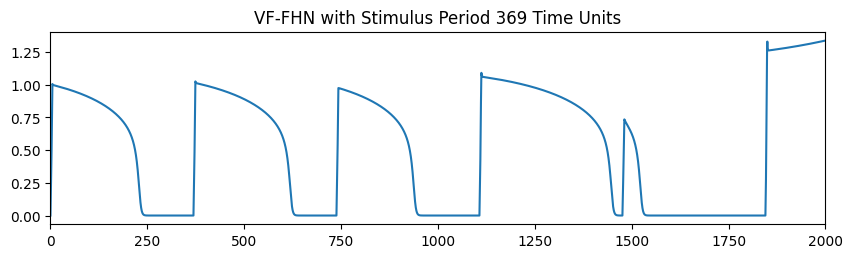

In [ ]:
# Compare how different stimulus periods affect the FHN VF-b waveforms.
for i in range(0,20):
    cur_period = 350. + i
    non_aut_func = functools.partial(logical_non_aut, period=cur_period, dur=5.0, mag=0.12)
    cur_states_fhn = odeint(fhn_vf_b, x_0_vf_b, t_vf_b, args=(non_aut_func,), hmax=0.1)

    cur_df_states_fhn = pd.DataFrame(cur_states_fhn, columns=['u','v'])
    cur_u_fhn = cur_df_states_fhn['u'].tolist()

    plt.plot(t_vf_b, cur_u_fhn)
    plt.title(f"VF-FHN with Stimulus Period {cur_period:.0f} Time Units")
    plt.xlim(0,2000)
    plt.gcf().set_size_inches(10, 2.5) # Change plot size so we quickly see differences in waveforms
    plt.show()

Based on the plots above, T = 361 time units gives the best result, with the VF-b variant of FHN seeming very sensitive to the correct stimulus period. Any variation from this value results in alternans and/or the stimulus occurring in the middle of an AP.

In [ ]:
# Generate the data using our non-autonomous term. Note that the period is very sensitive per the above experiment, so we must be careful in our selection of its value.
non_aut_func_vf_b = functools.partial(logical_non_aut, period=361, dur=5.0, mag=0.12)
states_vf_b = odeint(fhn_vf_b, x_0_vf_b, t_vf_b, args=(non_aut_func_vf_b,), hmax=0.1) # Test code --> lambda t: 0         Actual code --> non_aut_func_vf_b

In [ ]:
# Run SINDy on VF-FHN w/ time-varying terms.
# Note: There are some extraneous terms hiding around precision = 6-10 that show up
# TODO How to remove these terms?
opt_vf_b = ps.SSR(alpha=0.00001)
model_vf_b = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_vf_b)
model_vf_b.fit(states_vf_b, t=t_vf_b)
model_vf_b.print(precision=5)

(u)' = 0.00993 1 + 0.56846 u + -0.38539 v + 0.41556 u^2 + -5.33297 u v + 4.13045 v^2 + -0.98734 u^3 + 3.45733 u^2 v + 2.96049 u v^2 + -13.22186 v^3
(v)' = -0.00145 1 + 0.00705 u + -0.00500 u^2


Actual equations for comparison (without auto-oscillatory term $\delta$):

\begin{align}
    \dot{u} &= - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} &= -0.001455 + 0.00705u - 0.005u^2 \\
\end{align}

And with $\delta=1.0$:

\begin{align}
    \dot{u} &= - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} &= -0.001455 + 0.00705u - 0.005u^2 - 0.005v \\
\end{align}

Based on the result above, it seems we can identify $\dot{v}$, but not $\dot{u}$, when a stimulus is applied and not accounted for by SINDy.  This is to be expected since the stimulus term is only added to the $\dot{u}$ equation.

Text(0.5, 1.0, 'Values of u vs. v')

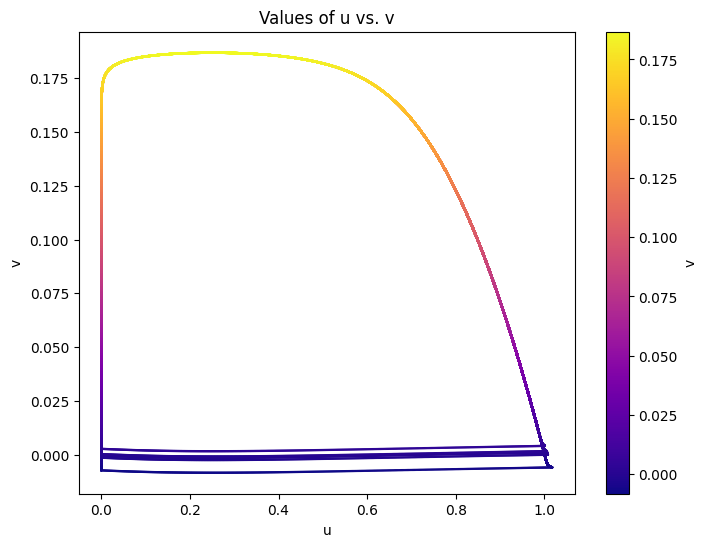

In [157]:
# Plot results - u vs. v
df_states_vf_b = pd.DataFrame(states_vf_b, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_vf_b['u'], 
    df_states_vf_b['v'], 
    c=df_states_vf_b['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v')

[0.0, 0.0015984165830601725, 0.0031936922840022316, 0.004785920257417133, 0.006375127992716763, 0.007961396414010832, 0.009544801273559963, 0.01112541289432394, 0.012703285845024899, 0.014278481923712578]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


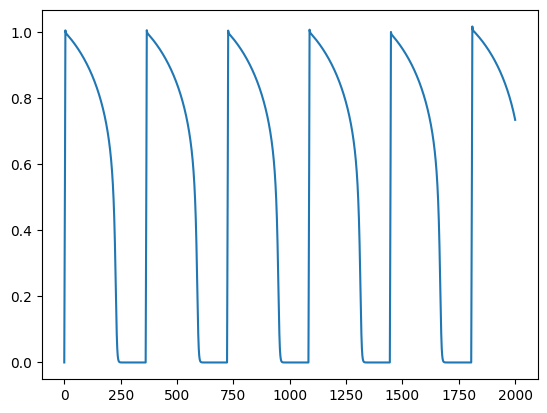

In [158]:
# Plot results - u vs. t
u_vf_b = df_states_vf_b['u'].tolist()
print(u_vf_b[0:10])
print(t_vf_b[0:10])

plt.plot(t_vf_b,u_vf_b)

# 2.) FHN
Now, fit standard FHN model with non-autonomous terms.

In [159]:
'''
Standard FitzHugh-Nagumo equations for comparison w/ the above method.
Params:
    state (2d array):        Contains the state variables u and v
    t (1d array):            Time input
    non_aut_term (1d array): A non-autonomous term to be added to the u_dot equation
    alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 0.0, eps = 0.005 (delta = 1.0 for auto-oscillatory state)
'''
def fhn(state, t, non_aut_term, alpha = 0.1, beta = 0.5, gamma = 1, delta = 0.0, eps = 0.01):
    u, v = state
    u_dot = u*(1-u)*(u-alpha) - v   # Note - The cardiac version without hyperpolarization (FHN-c) has -u*v instead of -v. ID success can change depending on which variant we use.
    v_dot = eps*(beta*u - gamma*v - delta)

    # Add time-dependent voltage perturbation
    u_dot +=  non_aut_term(t)
    return u_dot, v_dot

# FHN-c (cardiac variant of FHN) system definition
def fhn_c(state, t, non_aut_term, alpha = 0.1, beta = 1, gamma = 1.6, delta = 0.0, eps = 0.01):
    u, v = state
    u_dot = u*(1-u)*(u-alpha) - u*v   # Note - The cardiac version without hyperpolarization (FHN-c) has -u*v instead of -v. ID success can change depending on which variant we use.
    v_dot = eps*(beta*u - gamma*v - delta)

    # Add time-dependent voltage perturbation
    u_dot +=  non_aut_term(t)
    return u_dot, v_dot

# Standard FHN parameters
t_fhn = np.arange(0,2000,dt)
x_0_fhn = np.array([0,0])
states_fhn = odeint(fhn, x_0_fhn, t_fhn, args=(logical_non_aut,), hmax=0.1) # Test code --> lambda t: 0         Actual code --> logical_non_aut

In [160]:
# Run SINDy on FHN w/ time-varying terms.
# Note: There are some extraneous terms hiding around precision = 6-10 that show up, but they shouldn't affect the solution much.
# TODO How to remove these terms?
opt_fhn = ps.SSR(alpha=0.00001)
model_fhn = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_fhn)
model_fhn.fit(states_fhn, t=t_fhn)
model_fhn.print(precision=5)

(u)' = 0.03218 1 + 0.54900 u + 0.94559 v + -0.10030 u^2 + -7.80797 u v + -22.56224 v^2 + -0.48986 u^3 + 5.83089 u^2 v + 21.42264 u v^2 + 61.47220 v^3
(v)' = 0.00500 u + -0.01000 v + 0.00001 v^3


In [161]:
# TODO Why does using standard function library (e.g., removing feature_library argument) result in fewer extraneous terms?
model_fhn = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_fhn)
model_fhn.fit(states_fhn, t=t_fhn)
model_fhn.print(precision=5)

(u)' = 0.03218 1 + 0.54900 u + 0.94559 v + -0.10030 u^2 + -7.80797 u v + -22.56224 v^2 + -0.48986 u^3 + 5.83089 u^2 v + 21.42264 u v^2 + 61.47220 v^3
(v)' = 0.00500 u + -0.01000 v + 0.00001 v^3


Actual equations for comparison (without auto-oscillatory term $\delta$):

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1 uv - 1 u^3 \\
    \dot{v} &= 0.005 u - 0.01v \\
\end{align}

And with $\delta=1.0$:

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1uv - 1 u^3 \\
    \dot{v} &= - 0.01 + 0.005 u - 0.01v \\
\end{align}

Even with the simpler FHN model, we get the same result as with VF-FHN—the stimulus term must be taken into account in order for the $\dot{u}$ equation to be correctly identified.

Text(0.5, 1.0, 'Values of u vs. v')

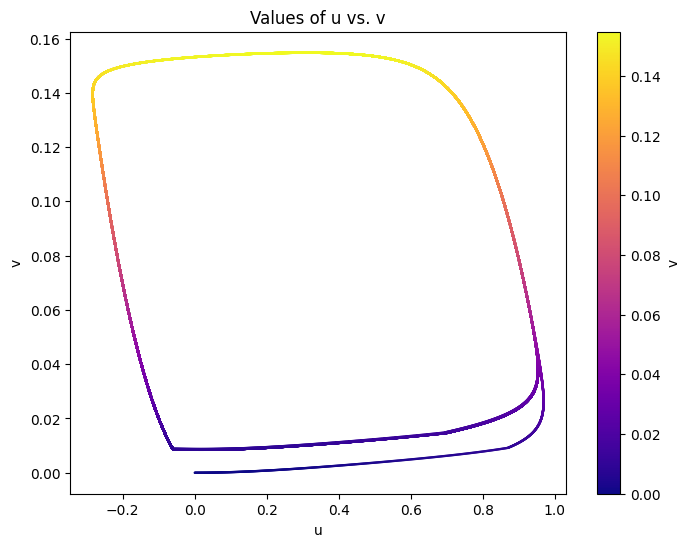

In [162]:
# Plot results - u vs. v
df_states_fhn = pd.DataFrame(states_fhn, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_fhn['u'], 
    df_states_fhn['v'], 
    c=df_states_fhn['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v')

[0.0, 0.0015984165830601725, 0.0031936922840022316, 0.004785920257417133, 0.006375127992716763, 0.007961396414010832, 0.009544801273559963, 0.01112541289432394, 0.012703285845024899, 0.014278481923712578]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


(0.0, 1000.0)

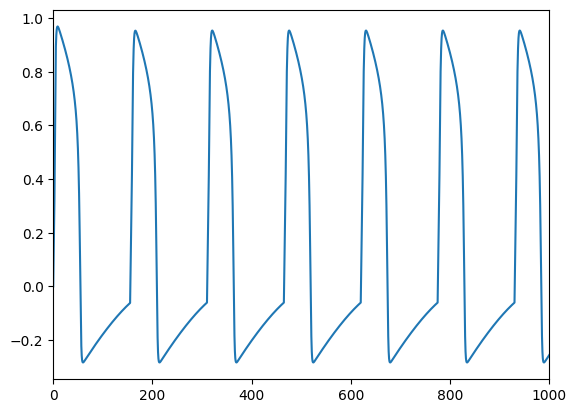

In [163]:
# Plot results - u vs. t
u_fhn = df_states_fhn['u'].tolist()
print(u_vf_b[0:10])
print(t_fhn[0:10])

plt.plot(t_fhn,u_fhn)
plt.xlim(0,1000)

# Experimental Section
Includes subtraction of logical_non_aut before passing to SINDy, FFT of voltage response, etc.

[0.0, 0.0011994098198587781, 0.002397651144048946, 0.0035947547308883116, 0.0047907558187071835, 0.005985674083706682, 0.007179547898377901, 0.008372413867041097, 0.009564306477421403, 0.010755250757803373]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


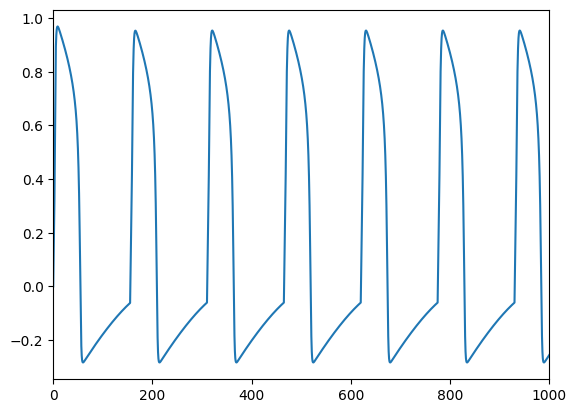

(0.0, 1000.0)

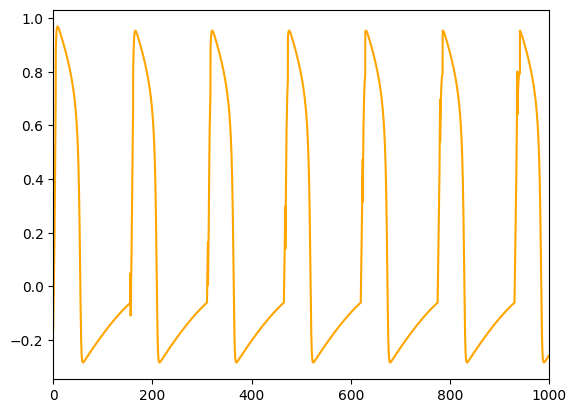

In [ ]:
u_fhn = df_states_fhn['u'].tolist()
print(u_fhn[0:10])
print(t_fhn[0:10])

# Plot result - u vs. t
plt.plot(t_fhn,u_fhn)
plt.xlim(0,1000)
plt.show()

# Now subtract the non-autonomous term to try to ID the original FHN dynamics. Because of the nonlinear effects, the spike at the peak will be slightly off, making this method not work particularly well.
plt.plot(t_fhn,u_fhn - logical_non_aut(t_fhn, period=156, dur=5, mag=0.12), color='orange')
plt.xlim(0,1000)

Text(0.5, 1.0, 'FFT of FHN u Values')

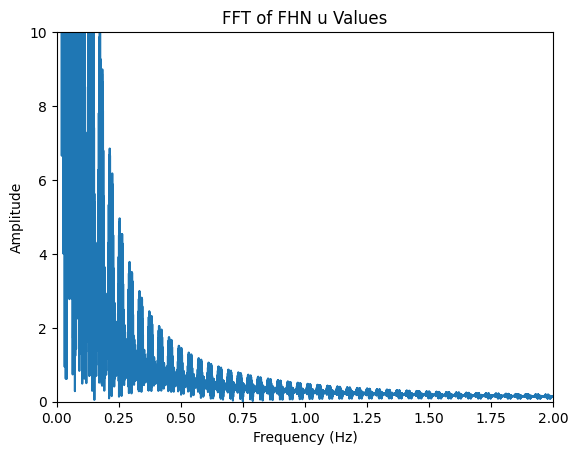

In [165]:
# Test analyzing time series in frequency space to see if we can tease out the non-autonomous signal.
# TODO Figure out what whether scipy.fft is being used incorrectly
w_fhn = fft.fft(u_fhn)
w_fhn = np.abs(w_fhn[0:len(w_fhn)//2]) # Take the first half of the FFT result, making sure to make all values real.
w = np.arange(0, 10, dt / 100.)
plt.plot(w, w_fhn)
plt.ylim(0, 10)
plt.xlim(0, 2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('FFT of FHN u Values')

# 3.) Using GeneralizedLibrary to ID Non-Autonomous Terms
We can use pySINDy's `GeneralizedLibrary` class to combine multiple `CustomLibrary` instances while also restricting which functions can apply to which equations using the argument inputs_per_library. This is useful since we know that the time-dependent term will only appear in the $u$ (voltage) equation.

In [208]:
# Define class to create a GeneralizedLibrary and fit FHN with a specified non-autonomous term.
class GenLibraryFit():
    '''
    Initialize the class with a non-autonomous term function.
    Params:
        func (function): A function that takes time as input and returns a non-autonomous term.
        non_aut_term_data (function): A function that takes time as input and returns a non-autonomous term for data generation.
        non_aut_term_fit (function): A function that takes time as input and returns a non-autonomous term for fitting.
        fhn_variant (string): The variant of the FitzHugh-Nagumo equations to use - "standard" for FHN, "cardiac" for FHN-c, and "vf" for VF-b variant.
    '''
    def __init__(self, non_aut_term_data, non_aut_term_fit, fhn_variant="standard"):
        # Generate data w/ standard FHN parameters
        self.t_fhn_td = np.arange(0,2000,dt)
        self.x_0_fhn_td = np.array([-0.1,0])    # TODO adjust v_0; may want a bit lower

        self.non_aut_term_data = non_aut_term_data
        self.non_aut_term_fit = non_aut_term_fit
        
        if fhn_variant == "standard":
            self.fhn_variant = self.fhn_td
        elif fhn_variant == "cardiac":
            self.fhn_variant = self.fhn_c_td
        elif fhn_variant == "vf":
            self.fhn_variant = self.fhn_vf_b_td

        # Generate u, v, and t data. Concatenate the t terms instead of directly solving for them since they are trivial.
        self.states_fhn_td = odeint(self.fhn_variant, self.x_0_fhn_td, self.t_fhn_td, hmax=0.1) # Test --> lambda t: 0       Actual --> logical_non_aut
        # plt.plot(t_fhn_td, states_fhn_td[:, 0], label='u')
        self.states_fhn_td = np.concatenate((self.states_fhn_td, self.t_fhn_td.reshape(-1, 1)), axis=1)

        # print(t_fhn_td.shape)
        # print(states_fhn_td.shape)
        # print(states_fhn_td[0:10,:])

    '''
    FitzHugh-Nagumo equations modified with an additional equation for time.
    Params:
        state (2d array):        Contains the state variables u and v
        t (1d array):            Time input
        non_aut_term (1d array): A non-autonomous term to be added to the u_dot equation
        alpha, beta, gamma, delta, eps, [theta, mu] (float): Parameters for the FHN equations.
    '''
    # Define standard FHN w/ non_aut_term_data term
    def fhn_td(self, state, t, alpha = 0.1, beta = 0.5, gamma = 1, delta = 0.0, eps = 0.01):
        return fhn(state, t, self.non_aut_term_data, alpha, beta, gamma, delta, eps)
    
    # Define cardiac FHN w/ non_aut_term_data term
    def fhn_c_td(self, state, t, alpha = 0.1, beta = 0.5, gamma = 1, delta = 0.0, eps = 0.01):
        return fhn_c(state, t, self.non_aut_term_data, alpha, beta, gamma, delta, eps)
    
    # Define VF-b variant of FHN w/ non_aut_term_data term
    def fhn_vf_b_td(self, state, t, alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 0.0, eps = 0.005, theta = -0.05, mu = 1.0):
        return fhn_vf_b(state, t, self.non_aut_term_data, alpha, beta, gamma, delta, eps, theta, mu)

    '''
    Fit the model using a GeneralizedLibrary with variable-specific libraries for u, v, and t.
    Params:
        non_aut_func (function): A function that takes time as input and returns a non-autonomous term.
    '''
    def fit(self):
        # Define variable-specific functions
        u_functions = [
            lambda u: u, 
            lambda u: u**2, 
            lambda u: u**3
        ]

        v_functions = [
            lambda v: v
        ]

        t_functions = [
            lambda t: 1.0,
            self.non_aut_term_fit
        ]

        # TODO Change the above to use PolynomialLibrary
        # ps.PolynomialLibrary(degree=3)
        # concat_library = ps.ConcatLibrary([ps.PolynomialLibrary(degree=3), custom_library])


        '''
        Create variable-specific libraries
        '''
        u_library = ps.CustomLibrary(library_functions=u_functions,
                                            function_names=[lambda u: u, lambda u: u + '^2', lambda u: u + '^3'])
        v_library = ps.CustomLibrary(library_functions=v_functions,
                                            function_names=[lambda v: v])
        t_library = ps.CustomLibrary(library_functions=t_functions,
                                            function_names=[lambda t: 1, lambda t: 'f_td(' + t + ')'])

        '''
        Specify which inputs to use for each of the u', v', and t' equations.  I.e.:
            u_library: Contains only functions of u (index 0)
            v_library: Contains only functions of v (index 1)
            t_library: Contains only functions of t (index 2)
        '''
        inputs_per_library = np.array([[0], 
                                        [1], 
                                        [2]])
        gen_library = ps.GeneralizedLibrary([u_library, v_library, t_library], inputs_per_library=inputs_per_library)


        # Fit SINDy model
        out = gen_library.fit(self.states_fhn_td)
        out = gen_library.transform(self.states_fhn_td)

        # Do the SINDy fit
        model_fhn_td = ps.SINDy(feature_names=["u", "v", "t"], feature_library=gen_library, optimizer=ps.SSR(alpha=0.00001))
        model_fhn_td.fit(self.states_fhn_td, t=self.t_fhn_td)
        model_fhn_td.print(precision=5)

In [ ]:
# TODO Calling w/ functools.partial() results in no .__code__ on pySINDy call, so have to define functions explicitly; would like to refactor in better way.
# Define battery of similar non-autonomous terms on which to test SINDy with the GeneralizedLibrary implementation above.
# Recall - 0.12 approximately optimal stimulus (for period 0.08 * 1.5 --> 0.12).
func_test = lambda t: (np.sin(0.01*t))**2
def func_log(t):
    return logical_non_aut(t, period=155.0, dur=5.0, mag=0.12)
def func_smooth(t):
    return smooth_non_aut(t, mag=0.12)
def func_smooth_old(t):
    return smooth_non_aut_old(t, mag=0.12)
funcs = [func_test, func_log, func_smooth, func_smooth_old]

### a.) FHN Test

In [210]:
# Test fit with same data and fitting non-autonomous terms.
for func in funcs:
    print(f"Fitting with function: {func.__name__}")
    cur_gen_library_a = GenLibraryFit(func, func, fhn_variant="standard")
    cur_gen_library_a.fit()
    print('\n\n')

Fitting with function: <lambda>
(u)' = -0.10000 u + 1.10000 u^2 + -1.00000 u^3 + -1.00000 v + 1.00000 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1



Fitting with function: func_log
(u)' = -0.09994 u + 1.09966 u^2 + -0.99975 u^3 + -0.99983 v + 0.00001 1 + 0.99802 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1



Fitting with function: func_smooth
(u)' = -0.10001 u + 1.10014 u^2 + -0.99616 u^3 + -1.00008 v + 0.99984 f_td(t)
(v)' = 0.00500 u + 0.00001 u^3 + -0.01000 v
(t)' = 1.00000 1



Fitting with function: func_smooth_old
(u)' = -0.10000 u + 1.10000 u^2 + -1.00000 u^3 + -1.00000 v + 1.00000 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1





Actual equations for comparison:

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1 u^3 - 1 v + f_{td}(t) \\
    \dot{v} &= 0.005 u - 0.01v \\
\end{align}

In [211]:
# TODO Can't correctly ID w/ similar-looking non-autonomous functions; need to look into further.
# Test fit with different data and fitting non-autonomous terms.
print(f"Fitting logical_non_aut data with smooth_non_aut fit")
cur_gen_library_a = GenLibraryFit(func_log, func_smooth, fhn_variant="standard")
cur_gen_library_a.fit()
print('\n\n')

Fitting logical_non_aut data with smooth_non_aut fit
(u)' = -0.05388 u + 1.27544 u^2 + -1.25628 u^3 + -1.25923 v + 0.01859 1 + 0.21402 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1





Text(0.5, 1.0, 'Voltage vs. Time (FHN)')

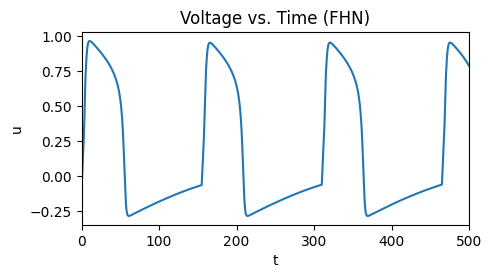

In [212]:
# Make sure voltage plots look correct.
plt.figure(figsize=(5, 2.5))
plt.plot(cur_gen_library_a.states_fhn_td[:, 2], cur_gen_library_a.states_fhn_td[:, 0], label='u vs. t')
plt.xlim(0, 500)
plt.xlabel('t')
plt.ylabel('u')
plt.title('Voltage vs. Time (FHN)')

### b.) FHN-c Test

In [213]:
# Test fit with same data and fitting non-autonomous terms.
for func in funcs:
    print(f"Fitting with function: {func.__name__}")
    cur_gen_library_b = GenLibraryFit(func, func, fhn_variant="cardiac")
    cur_gen_library_b.fit()
    print('\n\n')

Fitting with function: <lambda>
(u)' = 0.01798 u + 0.04450 u^2 + -0.10704 u^3 + -0.20927 v + 0.06649 1 + 0.15733 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1



Fitting with function: func_log
(u)' = -0.12523 u + 0.46219 u^2 + -0.38427 u^3 + -0.22112 v + 0.03290 1 + 1.07123 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1



Fitting with function: func_smooth
(u)' = -0.10597 u + 1.05074 u^2 + 0.24622 u^3 + -0.00021 v + 1.00122 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1



Fitting with function: func_smooth_old
(u)' = -0.10022 u + 0.45282 u^2 + -0.41368 u^3 + -0.29392 v + 0.04402 1 + 0.94680 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1





Text(0.5, 1.0, 'Voltage vs. Time (FHN-c)')

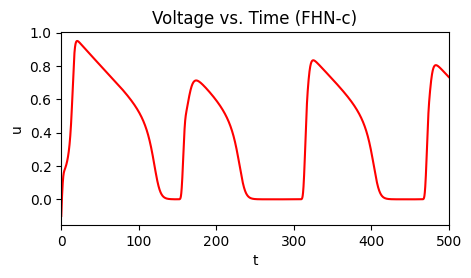

In [214]:
# Make sure voltage plots look correct.
plt.figure(figsize=(5, 2.5))
plt.plot(cur_gen_library_b.states_fhn_td[:, 2], cur_gen_library_b.states_fhn_td[:, 0], label='u vs. t', color='red')
plt.xlim(0, 500)
plt.xlabel('t')
plt.ylabel('u')
plt.title('Voltage vs. Time (FHN-c)')

### c.) VF-FHN Test

In [218]:
def func_log_vf(t):
    return logical_non_aut(t, period=361.0, dur=5.0, mag=0.12)
funcs_vf = [func_log_vf]

# Test fit with same data and fitting non-autonomous terms.
for func in funcs_vf:
    print(f"Fitting with function: {func.__name__}")
    cur_gen_library_c = GenLibraryFit(func, func, fhn_variant="vf")
    cur_gen_library_c.fit()
    print('\n\n')

Fitting with function: func_log_vf
(u)' = -0.18061 u + 0.47306 u^2 + -0.30063 u^3 + -0.07870 v + 0.00624 1 + 1.28148 f_td(t)
(v)' = 0.00705 u + -0.00500 u^2 + -0.00146 1
(t)' = 1.00000 1





Text(0.5, 1.0, 'Voltage vs. Time (VF-b FHN)')

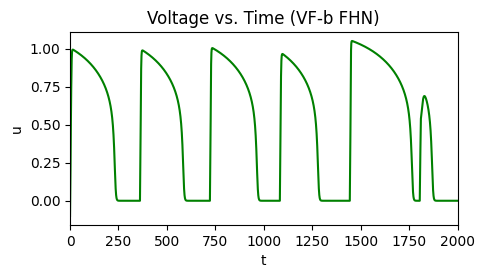

In [ ]:
# TODO VF-b has parameters slightly off based on t~1750
# Make sure voltage plots look correct.
plt.figure(figsize=(5, 2.5))
plt.plot(cur_gen_library_c.states_fhn_td[:, 2], cur_gen_library_c.states_fhn_td[:, 0], label='u vs. t', color='green')
plt.xlim(0, 2000)
plt.xlabel('t')
plt.ylabel('u')
plt.title('Voltage vs. Time (VF-b FHN)')

# 4.) Stimulus Amplitude Comparison

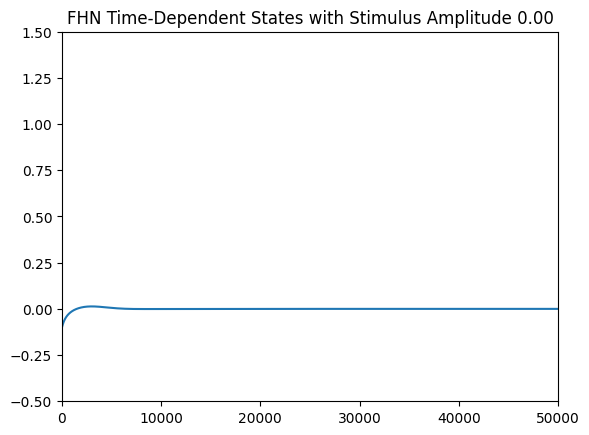

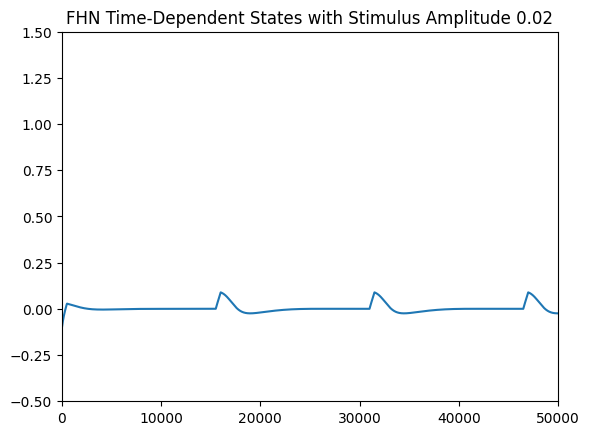

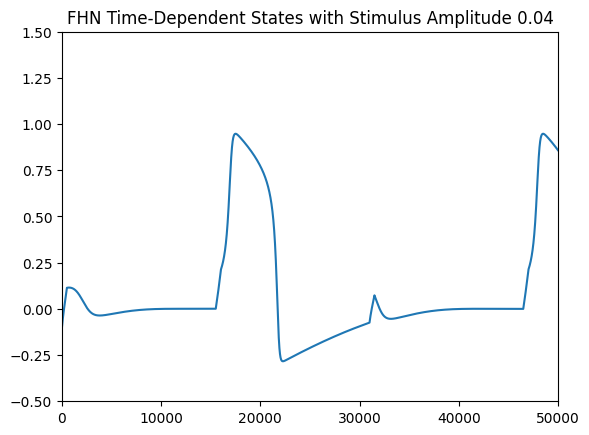

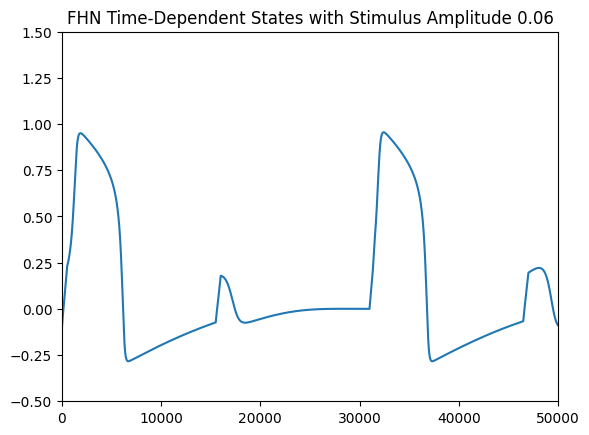

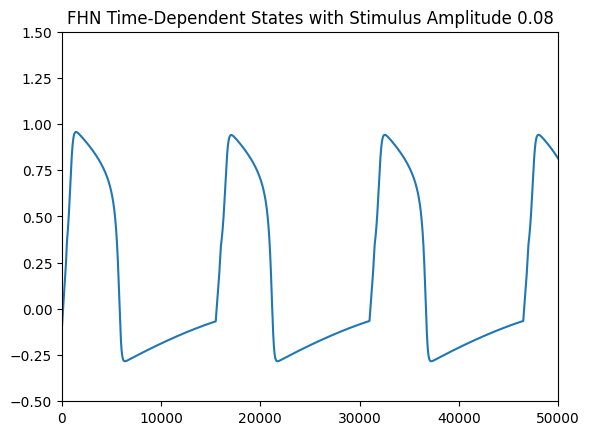

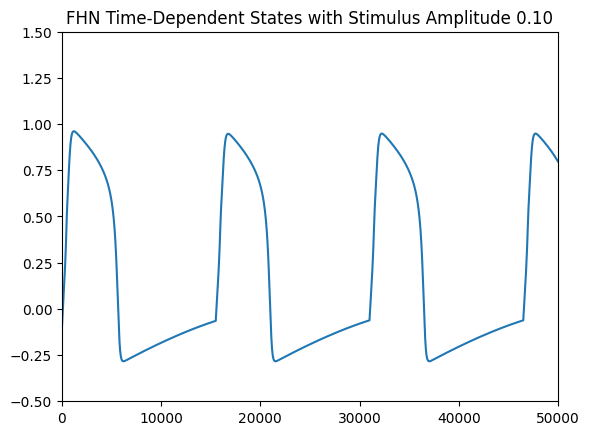

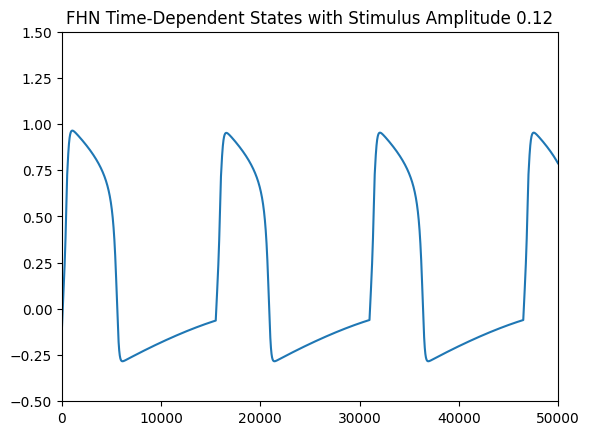

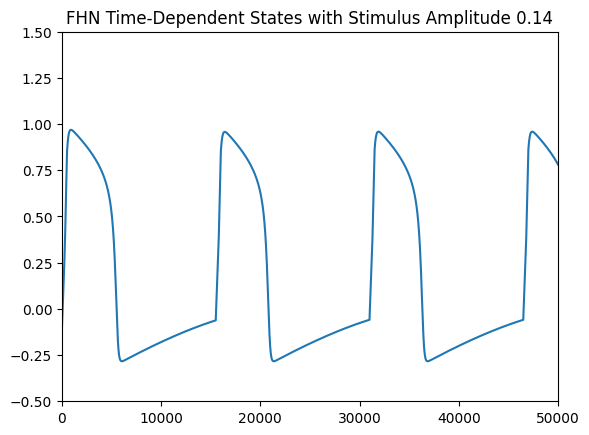

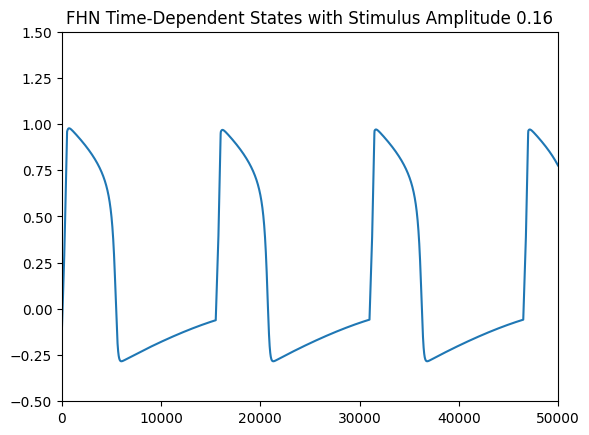

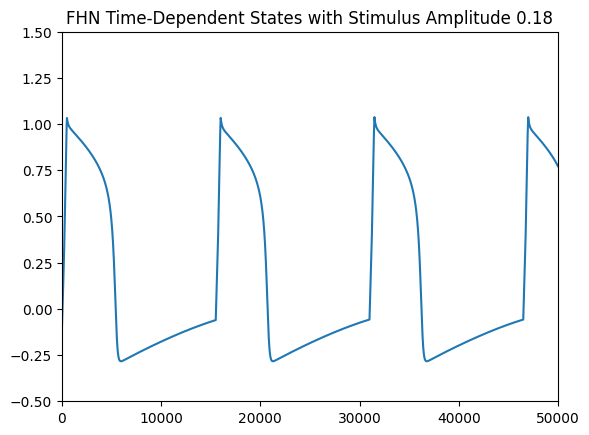

In [217]:
# Plot time-dependent FHN states for different stimulus amplitudes. The optimal amplitude will be around 1.5x to 2x the 
# first threshold amplitude that gives a good waveform (so ~1.5 * 0.08 = 0.12).
for amp in np.arange(0.0,0.2,0.02):
    states_fhn_td = odeint(fhn, cur_gen_library_a.x_0_fhn_td, cur_gen_library_a.t_fhn_td, args=(functools.partial(logical_non_aut, period=155.0, dur=5.0, mag=amp),), hmax=0.1) # Test --> lambda t: 0       Actual --> logical_non_aut
    plt.plot(states_fhn_td[:,0:1], label='u')
    plt.ylim(-0.5,1.5)
    plt.xlim(0,50000)
    plt.title(f"FHN Time-Dependent States with Stimulus Amplitude {amp:.2f}")
    plt.show()